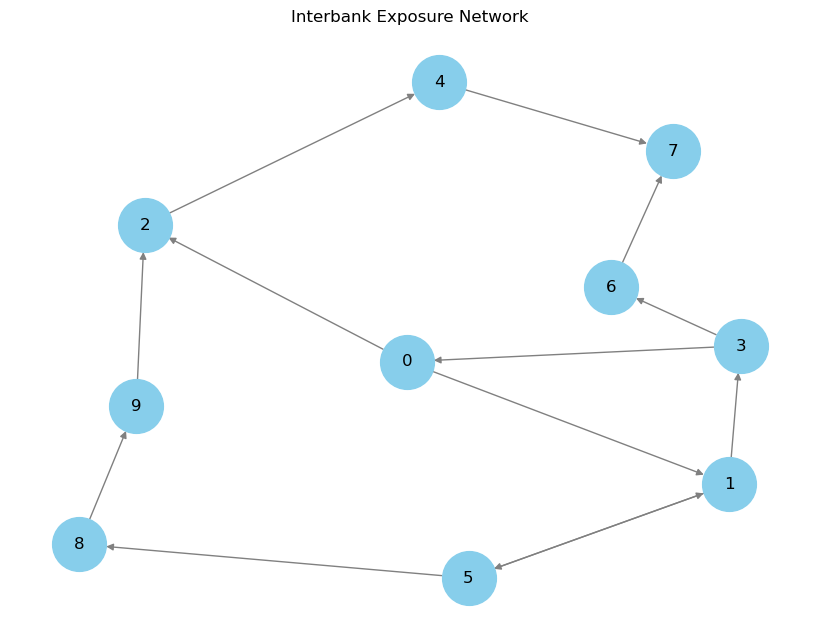

Balance Sheet, Network Features, and Systemic Impact:


,external_assets,external_liabilities,capital,in_degree,out_degree,pagerank,betweenness,systemic_impact
bank_id,,,,,,,,
0,1500,1200,300,100,230,0.058476,0.111111,0
1,2200,1900,300,270,550,0.083685,0.166667,0
2,800,750,50,140,40,0.134725,0.125000,2
3,1100,1000,100,200,190,0.058272,0.125000,0
4,500,460,40,40,20,0.146923,0.055556,0
5,3000,2600,400,350,420,0.077672,0.083333,1
6,950,880,70,90,30,0.055869,0.041667,0
7,400,380,20,50,0,0.204778,0.000000,0
8,1300,1180,120,300,150,0.079564,0.083333,0


Mean Squared Error: 0.87

Feature Importances for Systemic Risk:


,Feature,Importance
2,in_degree,0.397743
4,pagerank,0.181351
5,betweenness,0.164706
3,out_degree,0.149271
0,external_assets,0.082227
1,capital,0.024702


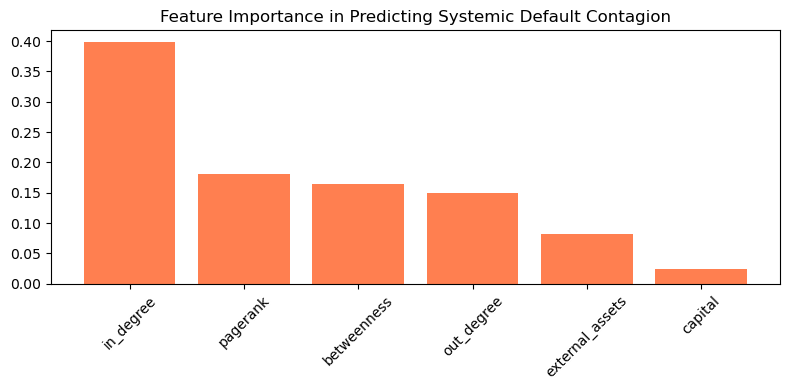

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import io
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

financials_csv = """bank_id,external_assets,external_liabilities,capital
0,1500,1200,300
1,2200,1900,300
2,800,750,50
3,1100,1000,100
4,500,460,40
5,3000,2600,400
6,950,880,70
7,400,380,20
8,1300,1180,120
9,600,550,50"""

exposures_csv = """lender_id,borrower_id,exposure
0,1,150
0,2,80
1,3,200
1,5,350
2,4,40
3,0,100
3,6,90
5,1,120
5,8,300
6,7,30
8,9,150
9,2,60
4,7,20"""

df_banks = pd.read_csv(io.StringIO(financials_csv)).set_index('bank_id')
df_edges = pd.read_csv(io.StringIO(exposures_csv))
G = nx.from_pandas_edgelist(df_edges, source='lender_id', target='borrower_id', edge_attr='exposure', create_using=nx.DiGraph())


df_banks['in_degree'] = pd.Series(dict(G.in_degree(weight='exposure'))) 
df_banks['out_degree'] = pd.Series(dict(G.out_degree(weight='exposure'))) 
df_banks['pagerank'] = pd.Series(nx.pagerank(G, weight='exposure'))
df_banks['betweenness'] = pd.Series(nx.betweenness_centrality(G))


df_banks = df_banks.fillna(0)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500, edge_color='gray', arrows=True)
plt.title("Interbank Exposure Network")
plt.show()



def simulate_cascade(initial_default_bank, df_banks, df_edges):
    defaulted = set([initial_default_bank])
    new_defaults = set([initial_default_bank])
    
    
    current_capital = df_banks['capital'].copy()
    
    while new_defaults:
        current_wave = new_defaults.copy()
        new_defaults = set()
        
        for defaulter in current_wave:
            
            lenders_to_defaulter = df_edges[df_edges['borrower_id'] == defaulter]
            
            for _, row in lenders_to_defaulter.iterrows():
                lender = row['lender_id']
                loss = row['exposure']
                
                if lender not in defaulted:
                    
                    current_capital[lender] -= loss
                    
                    
                    if current_capital[lender] < 0:
                        defaulted.add(lender)
                        new_defaults.add(lender)
                        
    return len(defaulted) - 1 


df_banks['systemic_impact'] = [simulate_cascade(bank, df_banks, df_edges) for bank in df_banks.index]

print("Balance Sheet, Network Features, and Systemic Impact:")
display(df_banks)

features = ['external_assets', 'capital', 'in_degree', 'out_degree', 'pagerank', 'betweenness']
X = df_banks[features]
y = df_banks['systemic_impact']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)


print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances for Systemic Risk:")
display(importance_df)

plt.figure(figsize=(8, 4))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='coral')
plt.title("Feature Importance in Predicting Systemic Default Contagion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()